# Los Angeles crime patterns & forecasting: analysis notebook

**Author:** Jeremiah Dibie · MSc Big Data Analytics, Data Visualisation module, University of Derby (2024)

**Data:** [Crime Data from 2020 to Present, LA Open Data](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8). Download the CSV, save it as `Crime_Data_from_2020_to_Present.csv` next to this notebook, then run all cells. The data is not included in the repository.

Notes on this published version:
- The interactive Folium map output (45 MB) was removed so the notebook renders on GitHub. A screenshot is in `images/incident_map.png`.
- An exploratory victim-descent classifier was removed. It used the victim-descent column to predict victim descent, so its 100% accuracy was trivial label leakage, and victim ethnicity is not an appropriate prediction target.

Exploring Crime Patterns and Predictive Analytics: A Case Study of Los Angeles

This project uses Python libraries for data analysis, visualization, and modeling. Key tools include Pandas, Matplotlib, NumPy, mpl_toolkits.mplot3d, Seaborn, Statsmodels, scikit-learn, TextBlob, WordCloud, nltk, and Foil. These libraries provide data structures, functions, and interactive visualizations for structured data. The project also uses Scikit-learn for machine learning, TextBlob for textual data processing, WordCloud for word frequency visualization, nltk for symbolic and statistical natural language processing, and Foil for geospatial data visualization. The project demonstrates various techniques for understanding and deriving insights from data.

In [1]:
import pandas as pd
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from textblob import TextBlob
from wordcloud import WordCloud
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import folium
from folium.plugins import MarkerCluster
import pkg_resources

# Function to get version of a package
def get_version(pkg_name):
    return pkg_resources.get_distribution(pkg_name).version

# Print versions of the libraries
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"statsmodels version: {sm.__version__}")
print(f"textblob version: {get_version('textblob')}")
print(f"wordcloud version: {get_version('wordcloud')}")
print(f"nltk version: {nltk.__version__}")
print(f"scikit-learn version: {get_version('scikit-learn')}")
print(f"folium version: {folium.__version__}")

pandas version: 2.1.1
matplotlib version: 3.7.1
numpy version: 1.24.3
seaborn version: 0.12.2
statsmodels version: 0.14.0
textblob version: 0.18.0.post0
wordcloud version: 1.9.3
nltk version: 3.8.1
scikit-learn version: 1.4.0
folium version: 0.16.0


Data Reading

In [2]:
df_crime = pd.read_csv('Crime_Data_from_2020_to_Present.csv')

In [3]:
print(df_crime.head())

       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0   10304468  01/08/2020 12:00:00 AM  01/08/2020 12:00:00 AM      2230     3   
1  190101086  01/02/2020 12:00:00 AM  01/01/2020 12:00:00 AM       330     1   
2  200110444  04/14/2020 12:00:00 AM  02/13/2020 12:00:00 AM      1200     1   
3  191501505  01/01/2020 12:00:00 AM  01/01/2020 12:00:00 AM      1730    15   
4  191921269  01/01/2020 12:00:00 AM  01/01/2020 12:00:00 AM       415    19   

     AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0    Southwest          377         2     624   
1      Central          163         2     624   
2      Central          155         2     845   
3  N Hollywood         1543         2     745   
4      Mission         1998         2     740   

                                         Crm Cd Desc  ... Status  \
0                           BATTERY - SIMPLE ASSAULT  ...     AO   
1                           BATTERY - SIMPLE ASSAULT  ...     IC   
2          SEX OFFEN

Dataset Description

In [4]:
df_crime.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,8.791060e+05,879106.000000,879106.000000,879106.000000,879106.000000,879106.000000,879106.000000,879096.000000,305086.000000,879095.000000,64196.000000,2167.000000,62.000000,879106.000000,879106.000000
mean,2.172299e+08,1336.557532,10.703378,1116.777896,1.411675,500.766151,29.676843,306.188760,363.310843,500.506316,957.747025,983.806645,990.983871,33.985957,-118.049475
std,1.128864e+07,653.328700,6.099808,609.985498,0.492137,207.639553,21.820113,217.107371,123.699129,207.428219,110.991166,52.599411,27.477259,1.730116,5.998066
min,8.170000e+02,1.000000,1.000000,101.000000,1.000000,110.000000,-3.000000,101.000000,101.000000,110.000000,210.000000,310.000000,821.000000,0.000000,-118.667600
25%,2.103127e+08,900.000000,6.000000,615.000000,1.000000,331.000000,0.000000,101.000000,310.000000,331.000000,998.000000,998.000000,998.000000,34.014200,-118.429700
50%,2.203188e+08,1415.000000,11.000000,1141.000000,1.000000,442.000000,31.000000,203.000000,400.000000,442.000000,998.000000,998.000000,998.000000,34.058500,-118.321500
75%,2.302153e+08,1900.000000,16.000000,1615.000000,2.000000,626.000000,45.000000,501.000000,400.000000,626.000000,998.000000,998.000000,998.000000,34.163500,-118.273900
max,2.499046e+08,2359.000000,21.000000,2199.000000,2.000000,956.000000,120.000000,976.000000,516.000000,956.000000,999.000000,999.000000,999.000000,34.334300,0.000000


In [5]:
print(df_crime.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879106 entries, 0 to 879105
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           879106 non-null  int64  
 1   Date Rptd       879106 non-null  object 
 2   DATE OCC        879106 non-null  object 
 3   TIME OCC        879106 non-null  int64  
 4   AREA            879106 non-null  int64  
 5   AREA NAME       879106 non-null  object 
 6   Rpt Dist No     879106 non-null  int64  
 7   Part 1-2        879106 non-null  int64  
 8   Crm Cd          879106 non-null  int64  
 9   Crm Cd Desc     879106 non-null  object 
 10  Mocodes         756810 non-null  object 
 11  Vict Age        879106 non-null  int64  
 12  Vict Sex        762804 non-null  object 
 13  Vict Descent    762796 non-null  object 
 14  Premis Cd       879096 non-null  float64
 15  Premis Desc     878571 non-null  object 
 16  Weapon Used Cd  305086 non-null  float64
 17  Weapon Des

Dataset Preprocessing

In [6]:
print(df_crime.isnull().sum())

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           122296
Vict Age               0
Vict Sex          116302
Vict Descent      116310
Premis Cd             10
Premis Desc          535
Weapon Used Cd    574020
Weapon Desc       574020
Status                 0
Status Desc            0
Crm Cd 1              11
Crm Cd 2          814910
Crm Cd 3          876939
Crm Cd 4          879044
LOCATION               0
Cross Street      740005
LAT                    0
LON                    0
dtype: int64


In [7]:
df_crime.dropna(subset=(['Vict Sex', 'Premis Desc', 'Vict Descent']), inplace=True)

In [8]:
print(df_crime.isnull().sum())

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes             6297
Vict Age               0
Vict Sex               0
Vict Descent           0
Premis Cd              0
Premis Desc            0
Weapon Used Cd    457492
Weapon Desc       457492
Status                 0
Status Desc            0
Crm Cd 1              10
Crm Cd 2          698365
Crm Cd 3          760102
Crm Cd 4          762205
LOCATION               0
Cross Street      644914
LAT                    0
LON                    0
dtype: int64


In [9]:
column_to_drop = [col for col in df_crime.columns if df_crime[col].isnull().any()]

In [10]:
print(column_to_drop)

['Mocodes', 'Weapon Used Cd', 'Weapon Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']


In [11]:
columns_to_drop = ['Mocodes','Crm Cd 2','Crm Cd 3','Crm Cd 4']

In [12]:
df_cleaned_specific = df_crime.drop(columns=columns_to_drop, inplace=False)

In [13]:
df_cleaned_specific['Date Rptd'] = pd.to_datetime(df_cleaned_specific['Date Rptd'], format='%m/%d/%Y %I:%M:%S %p')

In [14]:
df_cleaned_specific['DATE OCC'] = pd.to_datetime(df_cleaned_specific['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')

In [15]:
df_cleaned_specific['DATE OCC']

0        2020-01-08
1        2020-01-01
2        2020-02-13
3        2020-01-01
4        2020-01-01
            ...    
879096   2024-01-13
879100   2024-01-04
879103   2024-01-01
879104   2024-01-08
879105   2024-01-15
Name: DATE OCC, Length: 762267, dtype: datetime64[ns]

In [16]:
print(df_cleaned_specific.columns)

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Vict Age',
       'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'LOCATION', 'Cross Street', 'LAT', 'LON'],
      dtype='object')


In [17]:
unique_values = df_cleaned_specific['Crm Cd Desc'].unique()

In [18]:
print(unique_values)

['BATTERY - SIMPLE ASSAULT' 'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE'
 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)'
 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)'
 'RAPE, FORCIBLE' 'SHOPLIFTING - PETTY THEFT ($950 & UNDER)'
 'OTHER MISCELLANEOUS CRIME'
 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD'
 'BURGLARY FROM VEHICLE' 'CRIMINAL THREATS - NO WEAPON DISPLAYED' 'ARSON'
 'THEFT PLAIN - PETTY ($950 & UNDER)' 'ROBBERY'
 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT' 'BURGLARY'
 'BRANDISH WEAPON' 'INTIMATE PARTNER - SIMPLE ASSAULT' 'THEFT, PERSON'
 'BATTERY WITH SEXUAL CONTACT' 'BIKE - STOLEN'
 'INTIMATE PARTNER - AGGRAVATED ASSAULT' 'BATTERY POLICE (SIMPLE)'
 'TRESPASSING' 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)'
 'THEFT FROM MOTOR VEHICLE - ATTEMPT' 'THROWING OBJECT AT MOVING VEHICLE'
 'THEFT OF IDENTITY' 'BUNCO, GRAND THEFT' 'ATTEMPTED ROBBERY'
 'OTHER ASSAULT' 'BOMB SCARE' 'VIOLATION OF RESTRAINING ORDER'
 'SEXUAL PENETRATION W/FOREIGN OBJECT' 'VIO

In [19]:
print(f"Unique values in column '{'Crm Cd Desc'}':")
for value in unique_values:
    print(value)

Unique values in column 'Crm Cd Desc':
BATTERY - SIMPLE ASSAULT
SEX OFFENDER REGISTRANT OUT OF COMPLIANCE
VANDALISM - MISDEAMEANOR ($399 OR UNDER)
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)
RAPE, FORCIBLE
SHOPLIFTING - PETTY THEFT ($950 & UNDER)
OTHER MISCELLANEOUS CRIME
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD
BURGLARY FROM VEHICLE
CRIMINAL THREATS - NO WEAPON DISPLAYED
ARSON
THEFT PLAIN - PETTY ($950 & UNDER)
ROBBERY
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT
BURGLARY
BRANDISH WEAPON
INTIMATE PARTNER - SIMPLE ASSAULT
THEFT, PERSON
BATTERY WITH SEXUAL CONTACT
BIKE - STOLEN
INTIMATE PARTNER - AGGRAVATED ASSAULT
BATTERY POLICE (SIMPLE)
TRESPASSING
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)
THEFT FROM MOTOR VEHICLE - ATTEMPT
THROWING OBJECT AT MOVING VEHICLE
THEFT OF IDENTITY
BUNCO, GRAND THEFT
ATTEMPTED ROBBERY
OTHER ASSAULT
BOMB SCARE
VIOLATION OF RESTRAINING ORDER
SEXUAL PENETRATION W/FOREIGN OBJECT
VIOLATION OF COURT ORDER
SHOTS FIRED AT INHABITE

In [20]:
value_counts = df_cleaned_specific['Crm Cd Desc'].value_counts()

In [21]:
sorted_counts = value_counts.sort_values(ascending=False)

In [22]:
# Print the sorted counts of unique values
print(f"Counts of unique values in column '{'Crm Cd Desc'}' (sorted from max to min):")
for value, count in sorted_counts.items():
    print(f"{value}: {count}")

Counts of unique values in column 'Crm Cd Desc' (sorted from max to min):
BATTERY - SIMPLE ASSAULT: 69916
THEFT OF IDENTITY: 54665
BURGLARY FROM VEHICLE: 54219
BURGLARY: 53427
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS): 53296
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT: 50151
THEFT PLAIN - PETTY ($950 & UNDER): 44808
INTIMATE PARTNER - SIMPLE ASSAULT: 43940
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER): 31482
ROBBERY: 29993
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD: 28621
VANDALISM - MISDEAMEANOR ($399 OR UNDER): 23078
SHOPLIFTING - PETTY THEFT ($950 & UNDER): 21878
CRIMINAL THREATS - NO WEAPON DISPLAYED: 18052
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER): 15255
BRANDISH WEAPON: 13649
TRESPASSING: 13021
INTIMATE PARTNER - AGGRAVATED ASSAULT: 11925
VIOLATION OF RESTRAINING ORDER: 11073
LETTERS, LEWD  -  TELEPHONE CALLS, LEWD: 7299
BIKE - STOLEN: 7221
OTHER MISCELLANEOUS CRIME: 6308
VIOLATION OF COURT ORDER: 5994
BUNCO, GRAND THEFT: 5672
ATTEMPTED 

In [23]:
column_name = 'Crm Cd Desc'
specific_values = ['BATTERY - SIMPLE ASSAULT','BATTERY WITH SEXUAL CONTACT','BATTERY POLICE (SIMPLE)','BATTERY ON A FIREFIGHTER']

In [24]:
battery_filtered_df = df_cleaned_specific[df_cleaned_specific[column_name].isin(specific_values)]

Exploratory Data Analysis

In [25]:
# Filter the DataFrame to get counts of the specific value in the column
value_counts = battery_filtered_df[column_name].value_counts()

print(value_counts)

Crm Cd Desc
BATTERY - SIMPLE ASSAULT       69916
BATTERY WITH SEXUAL CONTACT     3855
BATTERY POLICE (SIMPLE)         2394
BATTERY ON A FIREFIGHTER         240
Name: count, dtype: int64


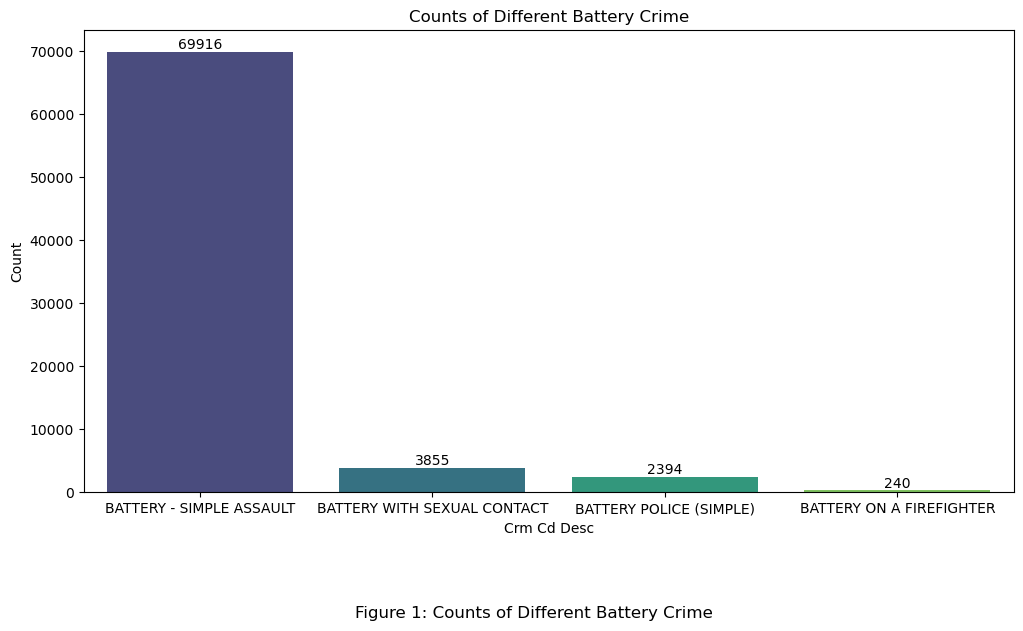

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
plt.title(f'Counts of Different Battery Crime')
plt.xlabel(column_name)
plt.ylabel('Count')
plt.xticks(rotation=0)

for i, value in enumerate(value_counts.values):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom')
    
# Adding the label "Figure 1: Counts of Different Battery Crime"
plt.figtext(0.5, -0.1, 'Figure 1: Counts of Different Battery Crime', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Now we created a new dataframe df_simple_assault because we want to streamline our analysis to just Battery - Simple Assault

In [27]:
df_simple_assault = battery_filtered_df[battery_filtered_df['Crm Cd Desc'] == 'BATTERY - SIMPLE ASSAULT']

We filtered the date to start from 2020-01-01 and end at 2023-12-31 because the 2024 record contains only January information which is not sufficient for our analysis. Therefore this analysis will focus on just 2020 to 2023

In [28]:
# Filter the DataFrame to include only dates between 2020 and 2023
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2023-12-31')
df_simple_assault = df_simple_assault[(df_simple_assault['Date Rptd'] >= start_date) & (df_simple_assault['Date Rptd'] <= end_date)]

Analysis of "Battery – Simple Assault" Cases from 2020 to 2023

In [29]:
# Analyze the number of Battery - Simple Assault reports per year within the date range
crime_counts_per_year = df_simple_assault['Date Rptd'].dt.year.value_counts().sort_index()

# Display the crime counts per year
print("\nNumber of Battery - Simple Assault Reports per Year (2020 to 2023):")
print(crime_counts_per_year)



Number of Battery - Simple Assault Reports per Year (2020 to 2023):
Date Rptd
2020    16224
2021    16148
2022    18036
2023    18900
Name: count, dtype: int64


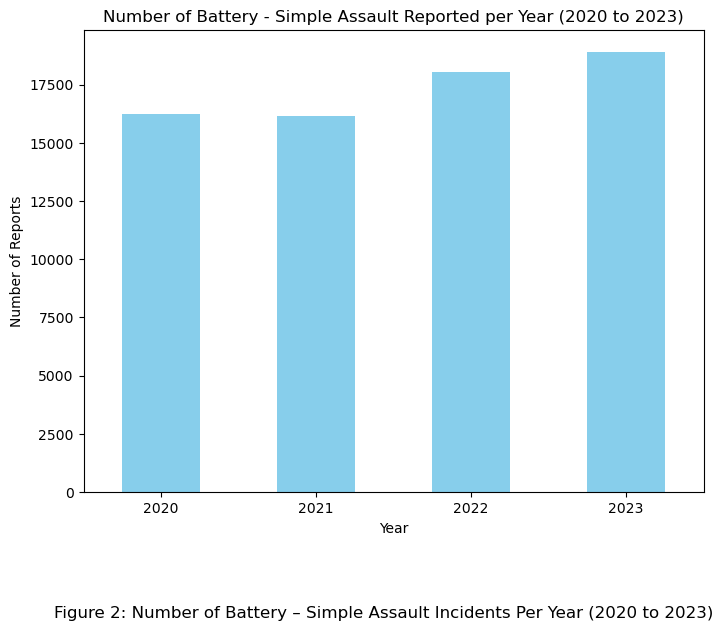

In [30]:
# Plotting the Battery - Simple Assault counts per year using matplotlib

plt.figure(figsize=(8, 6))
crime_counts_per_year.plot(kind='bar', color='skyblue')
plt.title('Number of Battery - Simple Assault Reported per Year (2020 to 2023)')
plt.xlabel('Year')
plt.ylabel('Number of Reports')
plt.xticks(rotation=0)

# Adding the label "Figure 1: Counts of Different Battery Crime"
plt.figtext(0.5, -0.1, 'Figure 2: Number of Battery – Simple Assault Incidents Per Year (2020 to 2023)', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [31]:
# Filter the DataFrame to include only dates between 2020 and 2023
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2023-12-31')
df_simple_assault = df_simple_assault[(df_simple_assault['DATE OCC'] >= start_date) & (df_simple_assault['DATE OCC'] <= end_date)]

# Analyze the number of Battery - Simple Assault occurred per year within the date range
crime_counts_per_year = df_simple_assault['DATE OCC'].dt.year.value_counts().sort_index()

# Display the crime counts per year
print("\nNumber of Battery - Simple Assault Occurrence per Year (2020 to 2023):")
print(crime_counts_per_year)


Number of Battery - Simple Assault Occurrence per Year (2020 to 2023):
DATE OCC
2020    16324
2021    16186
2022    18053
2023    18745
Name: count, dtype: int64


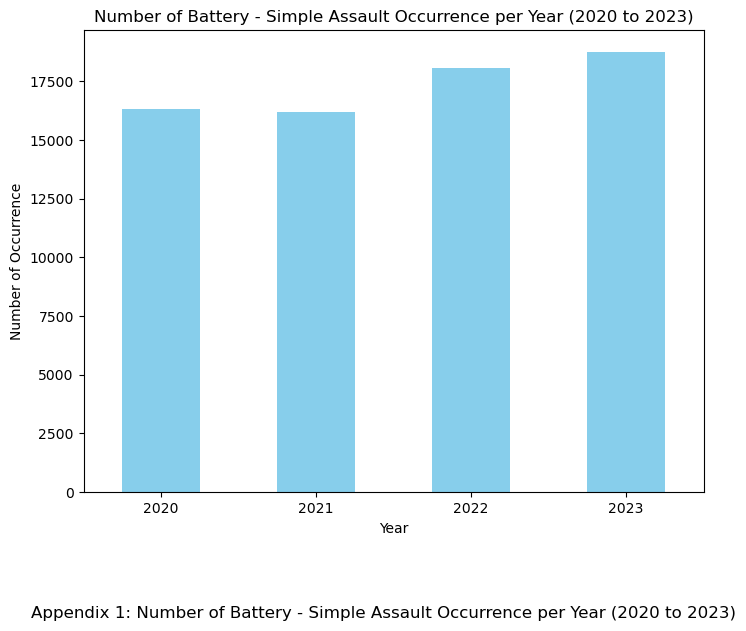

In [32]:
# Plotting the Battery - Simple Assault counts per year using matplotlib

plt.figure(figsize=(8, 6))
crime_counts_per_year.plot(kind='bar', color='skyblue')
plt.title('Number of Battery - Simple Assault Occurrence per Year (2020 to 2023)')
plt.xlabel('Year')
plt.ylabel('Number of Occurrence')
plt.xticks(rotation=0)
plt.figtext(0.5, -0.1, 'Appendix 1: Number of Battery - Simple Assault Occurrence per Year (2020 to 2023)', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

Monthly Analysis of "Battery – Simple Assault" Incidents from 2020 to 2023

In [33]:
# Extract month and day of the week from the 'Date Rptd' column
df_simple_assault['Month'] = df_simple_assault['Date Rptd'].dt.month
df_simple_assault['Day_of_Week'] = df_simple_assault['Date Rptd'].dt.dayofweek  # Monday=0, Sunday=6

In [34]:
# Group by month and count the number of incidents
monthly_counts = df_simple_assault.groupby('Month').size()

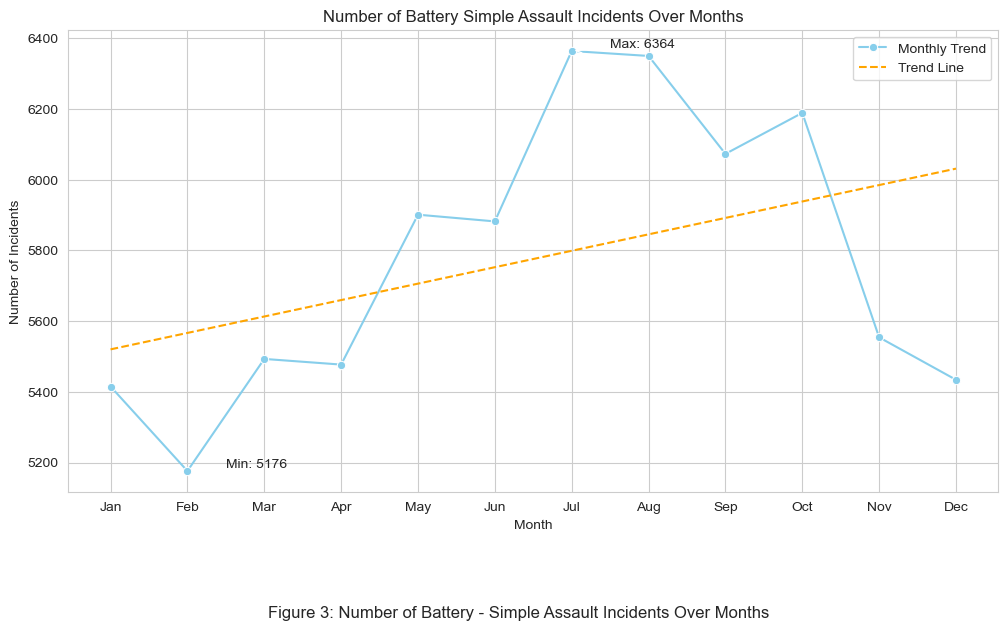

In [35]:
# Set style
sns.set_style("whitegrid")

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(12, 6))

# Plot monthly occurrence
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', color='skyblue', ax=ax, label='Monthly Trend')

# Add trend line
z = np.polyfit(monthly_counts.index, monthly_counts.values, 1)
p = np.poly1d(z)
sns.lineplot(x=monthly_counts.index, y=p(monthly_counts.index), color='orange', linestyle='--', ax=ax, label='Trend Line')

# Annotate max and min points
max_month = monthly_counts.idxmax()
min_month = monthly_counts.idxmin()
ax.annotate(f'Max: {monthly_counts[max_month]}', xy=(max_month, monthly_counts[max_month]),
             xytext=(max_month + 0.5, monthly_counts[max_month] + 10),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
ax.annotate(f'Min: {monthly_counts[min_month]}', xy=(min_month, monthly_counts[min_month]),
             xytext=(min_month + 0.5, monthly_counts[min_month] + 10),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

# Set title and labels
ax.set_title('Number of Battery Simple Assault Incidents Over Months')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Incidents')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.grid(True)
ax.legend()

# Adding the label 
plt.figtext(0.5, -0.1, 'Figure 3: Number of Battery - Simple Assault Incidents Over Months', wrap=True, horizontalalignment='center', fontsize=12)

# Show plot
plt.show()

Analysis of Battery Simple Assault Incident by Day of Week to find out the particular day that have the highest incident

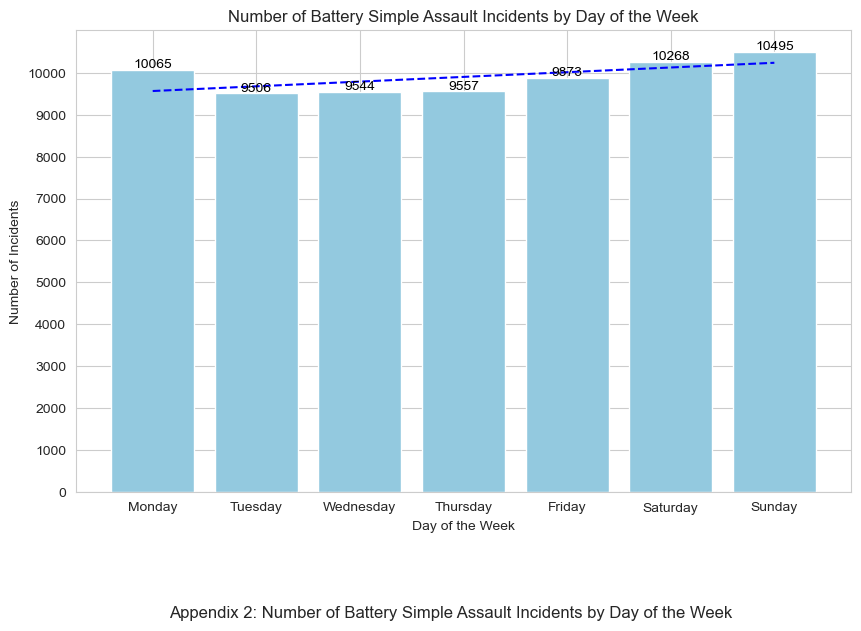

In [36]:
# Group by day of the week and count the number of incidents
day_of_week_counts = df_simple_assault.groupby('Day_of_Week').size()

# Set style
sns.set_style("whitegrid")

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(10, 6))

# Plot weekly occurrence
sns.barplot(x=day_of_week_counts.index, y=day_of_week_counts.values, color='skyblue', ax=ax)

# Add trend line
z = np.polyfit(day_of_week_counts.index, day_of_week_counts.values, 1)
p = np.poly1d(z)
plt.plot(day_of_week_counts.index, p(day_of_week_counts.index), color='blue', linestyle='--')

# Set title and labels
ax.set_title('Number of Battery Simple Assault Incidents by Day of the Week')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Number of Incidents')
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
ax.grid(True)

# Specify y-axis values
ax.set_yticks(np.arange(0, max(day_of_week_counts.values) + 1, 1000))  # Adjust the range and step size as needed

# Add annotations
for i, val in enumerate(day_of_week_counts.values):
    ax.text(i, val + 50, str(val), ha='center', color='black')
    
plt.figtext(0.5, -0.1, 'Appendix 2: Number of Battery Simple Assault Incidents by Day of the Week', wrap=True, horizontalalignment='center', fontsize=12)
# Show plot
plt.show()

Analysis of Battery Simple Assault by Time of Incident

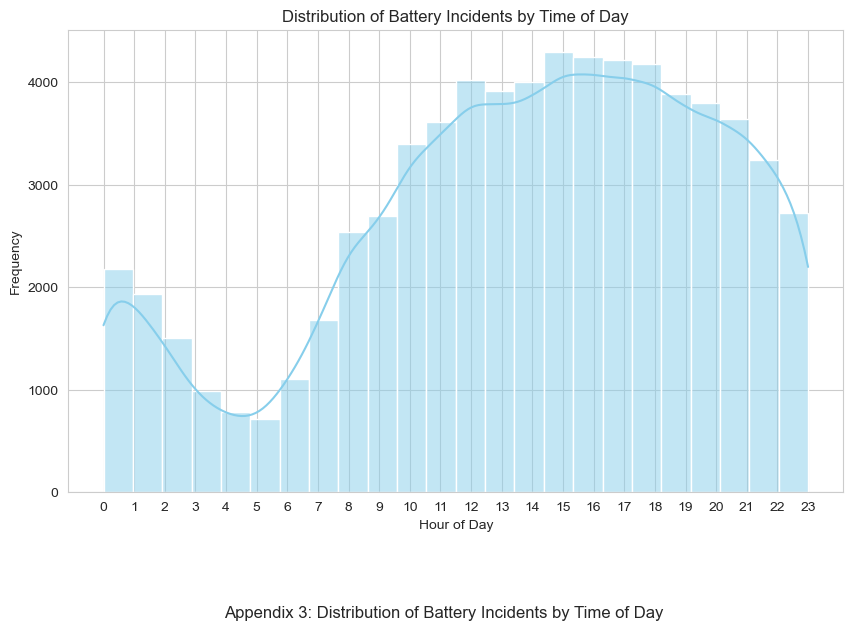

In [37]:
# Extract hour of the day from the 'TIME OCC' column
df_simple_assault['Hour_of_Day'] = df_simple_assault['TIME OCC'] // 100

# Analyze the distribution of incidents by time of day
plt.figure(figsize=(10, 6))
sns.histplot(df_simple_assault['Hour_of_Day'], bins=24, color='skyblue', kde=True)
plt.title('Distribution of Battery Incidents by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.grid(True)
plt.figtext(0.5, -0.1, 'Appendix 3: Distribution of Battery Incidents by Time of Day', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

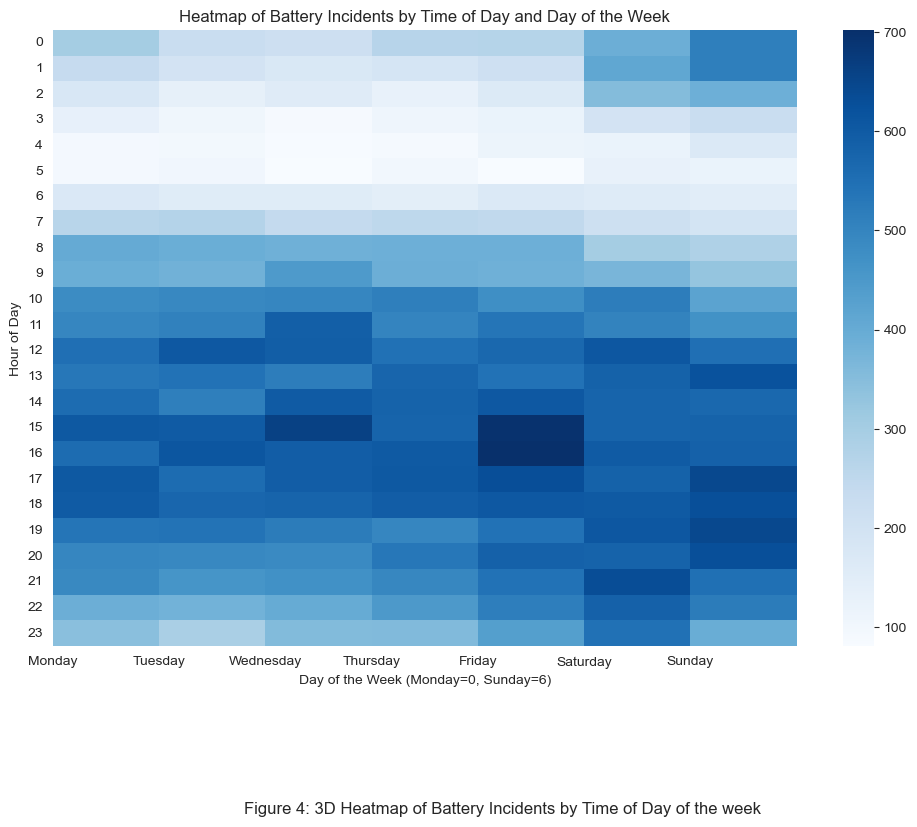

In [38]:
# Analyze the distribution of incidents by time of day and day of the week (heatmap)
hour_day_pivot = df_simple_assault.pivot_table(index='Hour_of_Day', columns=df_simple_assault['DATE OCC'].dt.dayofweek, aggfunc='size', fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(hour_day_pivot, cmap='Blues')
plt.title('Heatmap of Battery Incidents by Time of Day and Day of the Week')
plt.xlabel('Day of the Week (Monday=0, Sunday=6)')
plt.ylabel('Hour of Day')
plt.xticks(range(7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.yticks(rotation=0)
plt.figtext(0.5, -0.1, 'Figure 4: 3D Heatmap of Battery Incidents by Time of Day of the week', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

Analysis of the time difference (delay) between 'Date_Reported' and 'Date_Occurred'

In [39]:
# Calculate the time difference (delay) between 'Date_Reported' and 'Date_Occurred'
df_simple_assault['Delay_Days'] = (df_simple_assault['Date Rptd'] - df_simple_assault['DATE OCC']).dt.days

df_simple_assault['Delay_Days']

0         0
1         1
49        1
51        1
52        1
         ..
872364    1
872365    0
872366    0
872368    1
872371    0
Name: Delay_Days, Length: 69308, dtype: int64

In [40]:
# Analyze the average delay in reporting the crime
average_delay_days = df_simple_assault['Delay_Days'].mean()
average_delay_days

2.59241357419057

Analysis on the Area of Battery Simple Assault Incidents

In [41]:
# Count the number of incidents in each area and plot the distribution
area_counts = df_simple_assault['AREA NAME'].value_counts()
area_counts

AREA NAME
Central        6429
77th Street    4273
Hollywood      4180
Southwest      4136
Olympic        4127
Newton         3983
Rampart        3896
Southeast      3577
N Hollywood    3105
Pacific        3054
Wilshire       2963
Hollenbeck     2948
Harbor         2879
West LA        2686
Van Nuys       2617
Topanga        2531
West Valley    2492
Northeast      2464
Devonshire     2421
Mission        2339
Foothill       2208
Name: count, dtype: int64

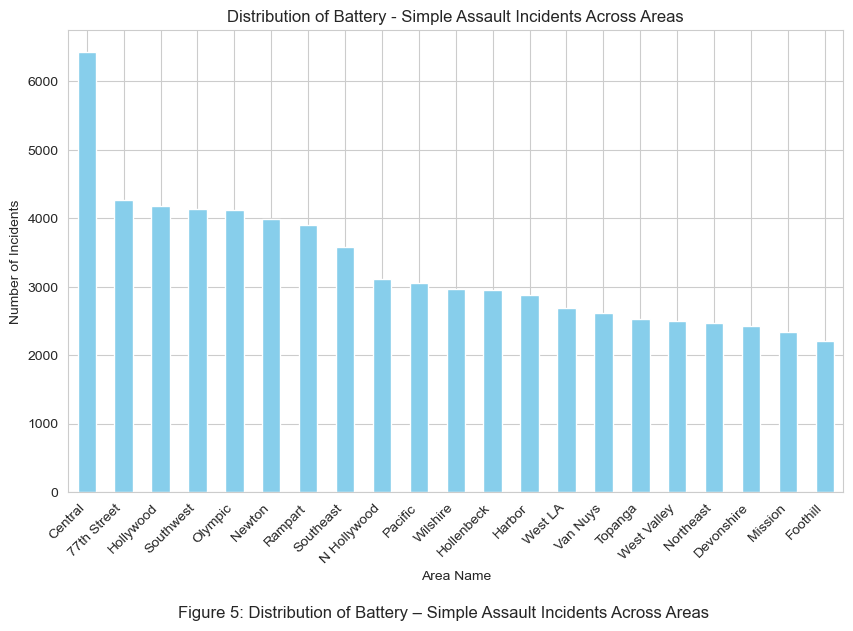

In [42]:
# Plotting the distribution of incidents across different areas using matplotlib
plt.figure(figsize=(10, 6))
area_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Battery - Simple Assault Incidents Across Areas')
plt.xlabel('Area Name')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
# Adding the label "Figure 1: Counts of Different Battery Crime"
plt.figtext(0.5, -0.1, 'Figure 5: Distribution of Battery – Simple Assault Incidents Across Areas', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Analysis of BAttery Simple Assault Victim Age
In order to have a good result in our analysis we decided to classify victim ages into age groups (children, adult, seniors)

In [43]:
# Classify victim ages into age groups (children, adult, seniors)
def classify_age_group(age):
    if age <= 16:
        return 'Children'
    elif age <= 64:
        return 'Adult'
    else:
        return 'Seniors'
    
df_simple_assault['Age Group'] = df_simple_assault['Vict Age'].apply(classify_age_group)
df_simple_assault['Age Group']

0            Adult
1            Adult
49           Adult
51           Adult
52           Adult
            ...   
872364       Adult
872365       Adult
872366       Adult
872368    Children
872371       Adult
Name: Age Group, Length: 69308, dtype: object

In [44]:
# Analyze and visualize the distribution of victim age groups
age_group_counts = df_simple_assault['Age Group'].value_counts()
age_group_counts

Age Group
Adult       59635
Seniors      5862
Children     3811
Name: count, dtype: int64

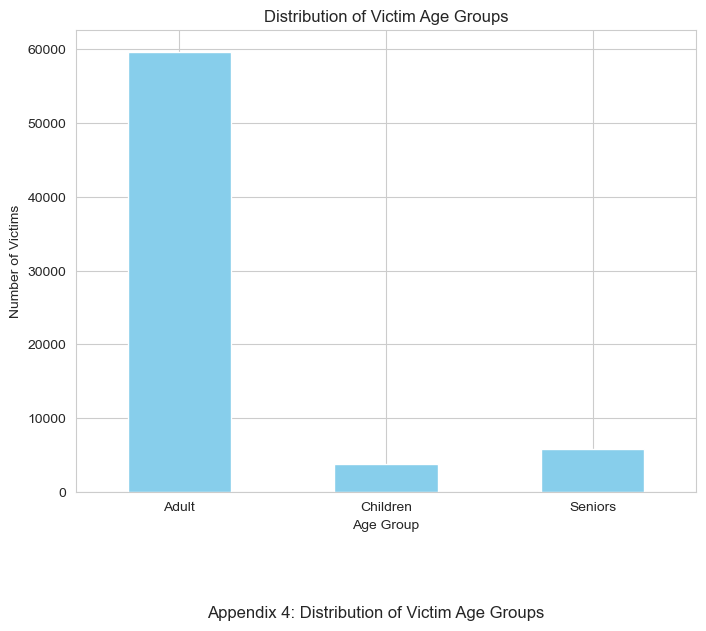

In [45]:
# Plotting the distribution of victim age groups using matplotlib
plt.figure(figsize=(8, 6))
age_group_counts.sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Victim Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Victims')
plt.xticks(rotation=0)
plt.figtext(0.5, -0.1, 'Appendix 4: Distribution of Victim Age Groups', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

Analysis on Battery Simple Assault Victim Gender
We decided to work with just three genders male, female and other gender, the X and H gender in our dataset was merged and named other gender.

In [46]:
unique_values_vict_sex = df_simple_assault['Vict Sex'].value_counts()
print(unique_values_vict_sex)

Vict Sex
M    36318
F    32577
X      406
H        7
Name: count, dtype: int64


In [47]:
unique_values_vict_sex = df_simple_assault['Vict Sex'].replace(['X', 'H',], 'Other Gender')
value_counts_sex = unique_values_vict_sex.value_counts()
print(value_counts_sex)
df_simple_assault['unique_values_vict_sex'] = unique_values_vict_sex

Vict Sex
M               36318
F               32577
Other Gender      413
Name: count, dtype: int64


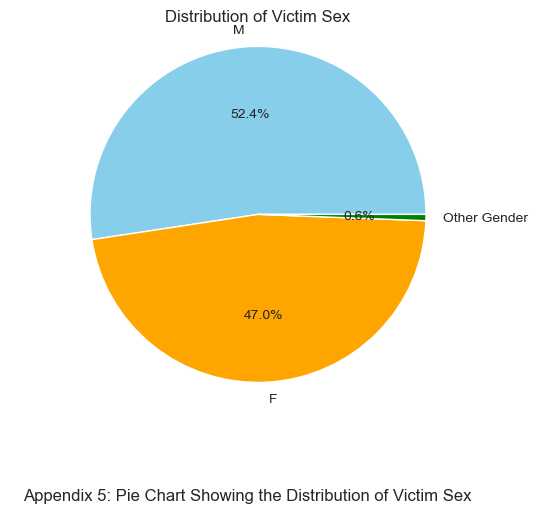

In [48]:
plt.pie(value_counts_sex, labels=value_counts_sex.index, autopct='%1.1f%%', colors=['skyblue', 'orange', 'green'])
plt.title('Distribution of Victim Sex')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.figtext(0.5, -0.1, 'Appendix 5: Pie Chart Showing the Distribution of Victim Sex ', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

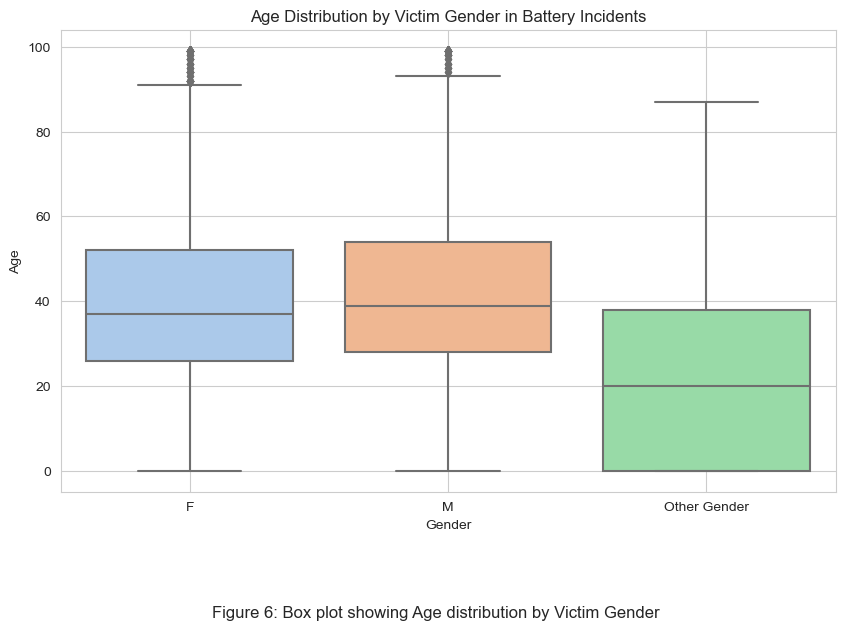

In [49]:
# Demographic Analysis - Age and Gender Relationship
plt.figure(figsize=(10, 6))
sns.boxplot(x=unique_values_vict_sex, y='Vict Age', data=df_simple_assault, palette='pastel')
plt.title('Age Distribution by Victim Gender in Battery Incidents')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.grid(True)

# Adding the label 
plt.figtext(0.5, -0.1, 'Figure 6: Box plot showing Age distribution by Victim Gender', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Descriptive Statistics of Victim Ages

In [50]:
# Display descriptive statistics of victim ages
print("\nDescriptive Statistics of Victim Ages:")
print(df_simple_assault['Vict Age'].describe())


Descriptive Statistics of Victim Ages:
count    69308.000000
mean        40.059041
std         16.889989
min          0.000000
25%         27.000000
50%         38.000000
75%         53.000000
max         99.000000
Name: Vict Age, dtype: float64


Analysis of Battery Simple Assault Premises Description to gain more insight on the premises with higher incidents

In [51]:
df_simple_assault = df_simple_assault.dropna(subset=['Premis Desc'])

missing_values_count = df_simple_assault['Premis Desc'].isnull().sum()
print("Number of missing values in 'Premis Desc' column:", missing_values_count)

Number of missing values in 'Premis Desc' column: 0


In [52]:
# Display unique values and their counts in the 'Premis Desc' column
premis_desc_counts = df_simple_assault['Premis Desc'].value_counts()
top_premis_desc = premis_desc_counts.head(5)
print(top_premis_desc)

Premis Desc
SINGLE FAMILY DWELLING                          11706
STREET                                          11006
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    10514
SIDEWALK                                         7949
PARKING LOT                                      4211
Name: count, dtype: int64


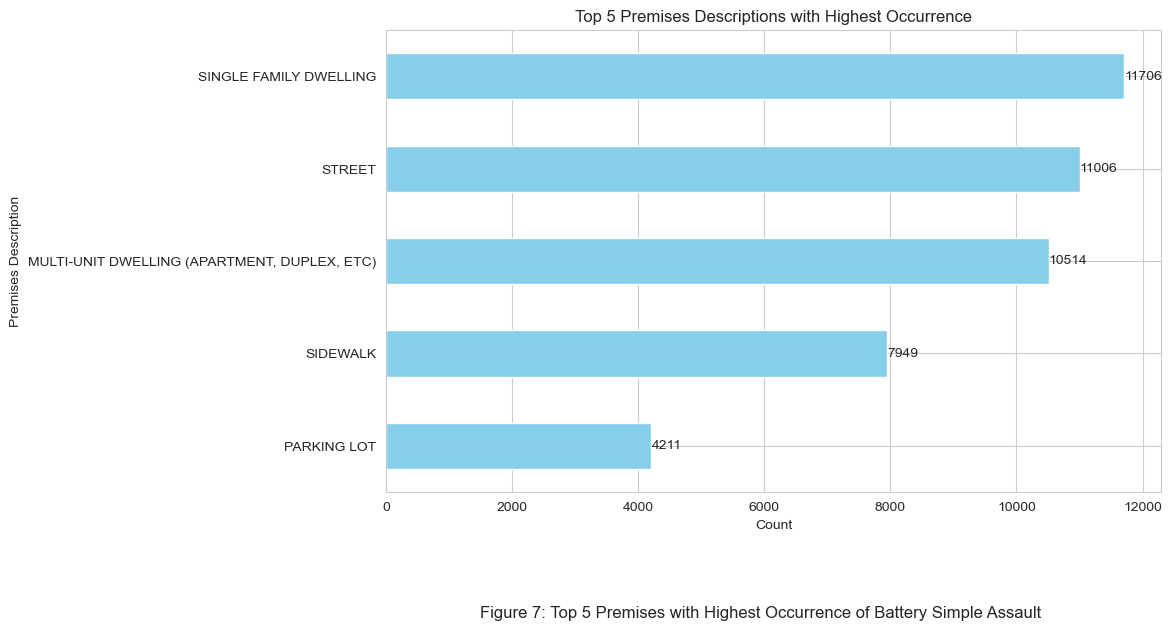

In [53]:
plt.figure(figsize=(10, 6))
top_premis_desc_sorted = top_premis_desc.sort_values()
bars = top_premis_desc_sorted.plot(kind='barh', color='skyblue', legend=False)

# Add counts as text on each bar
for i, v in enumerate(top_premis_desc_sorted):
    bars.text(v, i, str(v), ha='left', va='center')

plt.title('Top 5 Premises Descriptions with Highest Occurrence')
plt.xlabel('Count')
plt.ylabel('Premises Description')

# Adding the label
plt.figtext(0.5, -0.1, 'Figure 7: Top 5 Premises with Highest Occurrence of Battery Simple Assault', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Analysis of Weapon Used for the Battery Simple Assault

In [54]:
# Display unique values and their counts in the 'Weapon Desc' column
weapon_desc_counts = df_simple_assault['Weapon Desc'].value_counts()
print("\nUnique values and counts in 'Weapon Desc' column:")
print(weapon_desc_counts)



Unique values and counts in 'Weapon Desc' column:
Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    62565
UNKNOWN WEAPON/OTHER WEAPON                        5297
STICK                                               297
ROCK/THROWN OBJECT                                  279
VERBAL THREAT                                       166
BLUNT INSTRUMENT                                    158
BELT FLAILING INSTRUMENT/CHAIN                       81
FIXED OBJECT                                         72
BOTTLE                                               68
PIPE/METAL PIPE                                      41
SCALDING LIQUID                                      39
MACE/PEPPER SPRAY                                    30
VEHICLE                                              24
BOARD                                                22
CAUSTIC CHEMICAL/POISON                              20
KNIFE WITH BLADE 6INCHES OR LESS                     19
LIQUOR/DRUGS                             

In [55]:
# Select the top 6 weapons
top_6_weapons = weapon_desc_counts.head(6)

In [56]:
print(top_6_weapons)

Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    62565
UNKNOWN WEAPON/OTHER WEAPON                        5297
STICK                                               297
ROCK/THROWN OBJECT                                  279
VERBAL THREAT                                       166
BLUNT INSTRUMENT                                    158
Name: count, dtype: int64


With "Strong-Arm" (hands, fist, feet, or bodily force) being the most prevalent with 62,570 instances, policy recommendations might revolve around:

Training and Intervention: Provide training in non-violent conflict resolution techniques to law enforcement officers and community members to reduce the need for physical force in altercations.
Community Policing: Foster stronger relationships between law enforcement agencies and communities, encouraging dialogue and trust-building to prevent situations escalating to physical altercations.
Victim Support: Offer support services and resources for victims of strong-arm incidents to aid in recovery and prevent further violence.
Public Awareness: Launch public awareness campaigns highlighting the dangers and legal consequences of using physical force in altercations, emphasizing non-violent alternatives.
Data Monitoring: Implement systems for monitoring and analyzing trends in strong-arm incidents to inform targeted interventions and resource allocation.
By addressing these areas, policies can aim to reduce the prevalence of strong-arm incidents and promote safer communities.

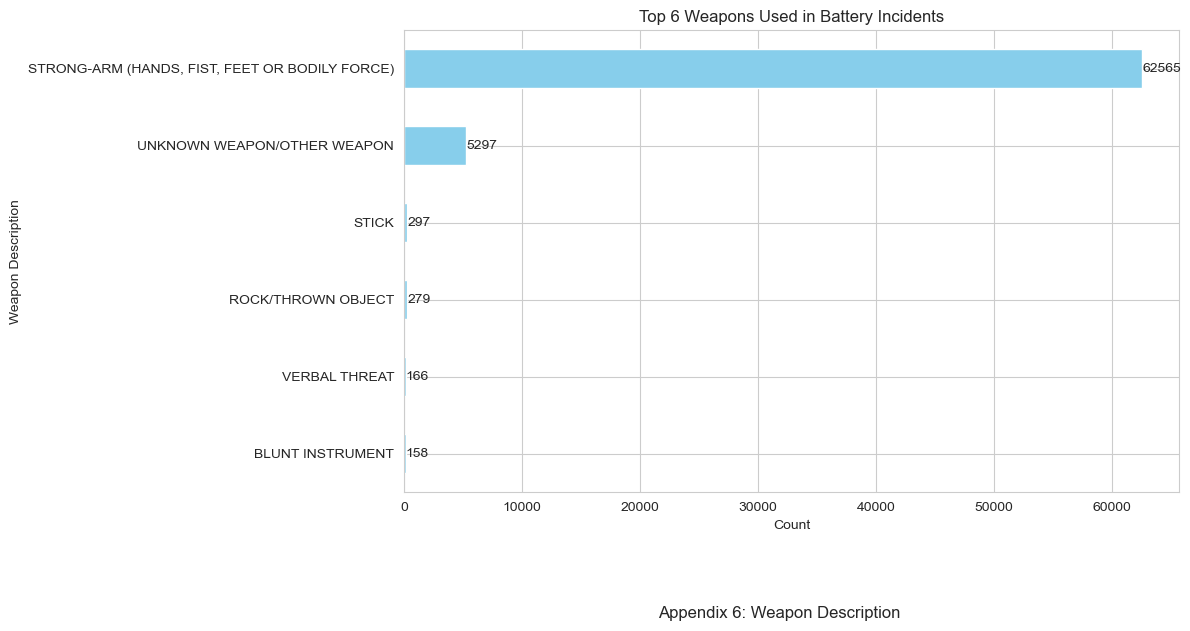

In [57]:
plt.figure(figsize=(10, 6))
top_6_weapons_sorted = top_6_weapons.sort_values()
bars = top_6_weapons_sorted.plot(kind='barh', color='skyblue')

# Add counts as text on each bar
for index, value in enumerate(top_6_weapons_sorted):
    bars.text(value, index, str(value), va='center', ha='left')

plt.title('Top 6 Weapons Used in Battery Incidents')
plt.xlabel('Count')
plt.ylabel('Weapon Description')
plt.figtext(0.5, -0.1, 'Appendix 6: Weapon Description', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

Analysis of Battery Simple Assault Status Description

We had 5 status which are investigation continued, adult arrest, adult other, juvenile arrest, and juvenile other, we decided to merge adult other and juvenile other as other status to gain more insight on the status of the crime incident

In [58]:
Status_Description = df_simple_assault['Status Desc'].value_counts()
print(Status_Description)

Status Desc
Invest Cont     47286
Adult Other     17025
Adult Arrest     4118
Juv Other         550
Juv Arrest        329
Name: count, dtype: int64


In [59]:
Status_Description = df_simple_assault['Status Desc'].replace(['Adult Other', 'Juv Other',], 'Other Status')

In [60]:
status_description_counts = Status_Description.value_counts()
print(status_description_counts)
df_simple_assault['status_description_counts'] = status_description_counts

Status Desc
Invest Cont     47286
Other Status    17575
Adult Arrest     4118
Juv Arrest        329
Name: count, dtype: int64


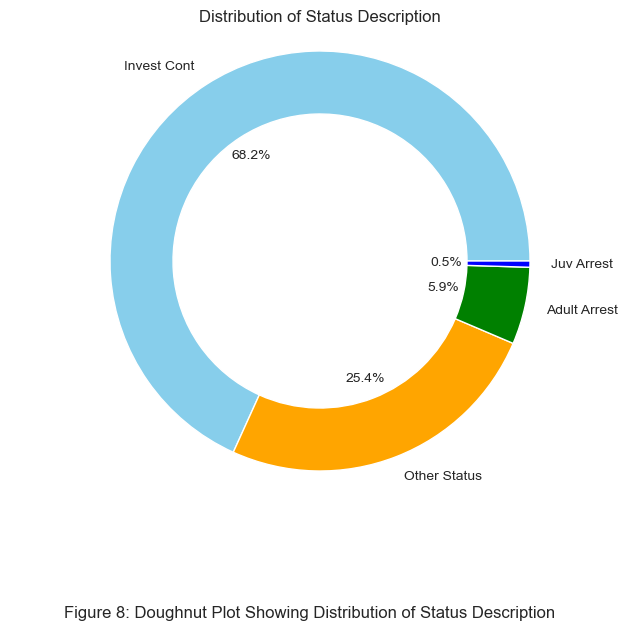

In [61]:
plt.figure(figsize=(8, 6))
plt.pie(status_description_counts, labels=status_description_counts.index, autopct='%1.1f%%', colors=['skyblue', 'orange', 'green', 'blue'], wedgeprops=dict(width=0.3))
plt.title('Distribution of Status Description')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a circle in the center to create a donut chart
circle = plt.Circle((0, 0), 0.2, color='white')

plt.gca().add_artist(circle)

# Adding the label
plt.figtext(0.5, -0.1, 'Figure 8: Doughnut Plot Showing Distribution of Status Description', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Analysis of Battery Simple Assault Victim Descent

In [62]:
Map_descent = {
   'A':'Other Asian','B':'Black','C':'Chinese','D':'Cambodian','F':'Filipino','G': 'Guamanian','H':'Hispanic/Latin/Mexican','I': 'American Indian/Alaskan Native' ,'J': 'Japanese', 'K':'Korean','L':'Laotian','O' : 'Other', 'P' : 'Pacific Islander','S': 'Samoan', 'U': 'Hawaiian', 'V': 'Vietnamese', 'W': 'White','X': 'Unknown', 'Z': 'Asian Indian'
}
df_simple_assault['Vict Descent'] = df_simple_assault['Vict Descent'].map(Map_descent)
Victim_Description = df_simple_assault['Vict Descent'].value_counts().reset_index()
print(Victim_Description)

                      Vict Descent  count
0           Hispanic/Latin/Mexican  34725
1                            Black  13626
2                            White  12825
3                            Other   5514
4                      Other Asian   1776
5                          Unknown    647
6                           Korean    127
7                         Filipino     21
8   American Indian/Alaskan Native     13
9                          Chinese     12
10                       Guamanian      5
11                        Japanese      5
12                        Hawaiian      4
13                      Vietnamese      3
14                    Asian Indian      2
15                Pacific Islander      2
16                          Samoan      1


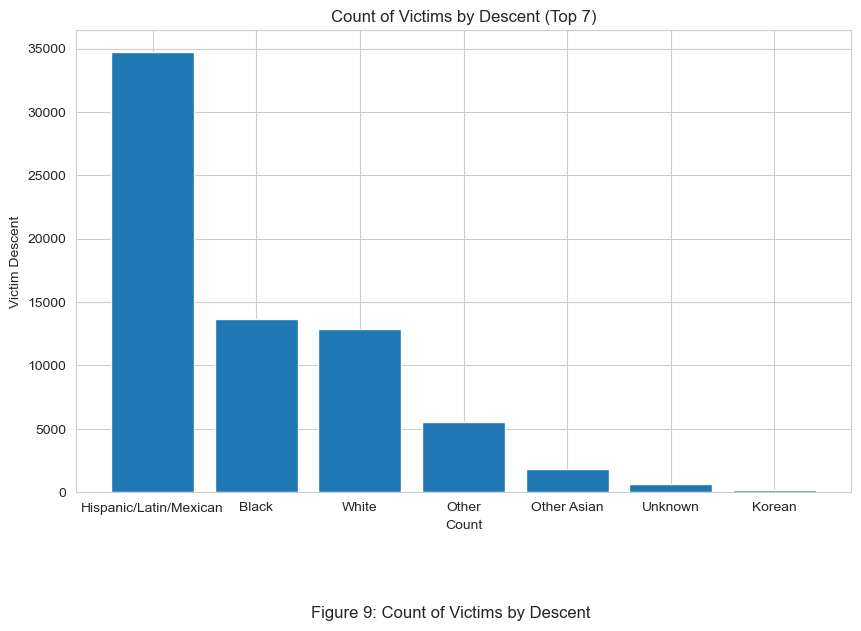

In [63]:
Victim_Description = df_simple_assault['Vict Descent'].value_counts().reset_index()

# Selecting only the top 7 values
top_7_values = Victim_Description.head(7)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(top_7_values['Vict Descent'], top_7_values['count'])
plt.ylabel('Victim Descent')
plt.xlabel('Count')
plt.title('Count of Victims by Descent (Top 7)')
plt.xticks(rotation=0)  # Rotating x-axis labels for better readability

# Adding the label
plt.figtext(0.5, -0.1, 'Figure 9: Count of Victims by Descent', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()


Analysis of the Geographical Location of Battery Simple Assault Incident

In [64]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [65]:
import folium
from folium.plugins import MarkerCluster

# Create a map centered around the mean latitude and longitude values
m = folium.Map(location=[df_simple_assault['LAT'].mean(), df_simple_assault['LON'].mean()], zoom_start=12)

# Create a MarkerCluster object
marker_cluster = MarkerCluster().add_to(m)

# Define colors for different types of battery incidents (customize as needed)
colors = {
    'BATTERY - SIMPLE ASSAULT': 'blue',
    'BATTERY WITH SEXUAL CONTACT': 'red',
    'BATTERY POLICE (SIMPLE)': 'green',
    'BATTERY ON A FIREFIGHTER': 'orange'
}

# Iterate over each battery incident and add a marker to the MarkerCluster with appropriate color
for idx, row in df_simple_assault.iterrows():
    folium.Marker([row['LAT'], row['LON']], icon=folium.Icon(color=colors[row['Crm Cd Desc']])).add_to(marker_cluster)

# Adding the label "Figure 1: Counts of Different Battery Crime"
plt.figtext(0.5, -0.1, 'Figure 8: Geographical distribution of battery incidents', wrap=True, horizontalalignment='center', fontsize=12)

# Display the map
m

[Interactive Folium map output removed to keep this notebook viewable on GitHub (45 MB). A screenshot is in images/incident_map.png.]


Correlation Analysis

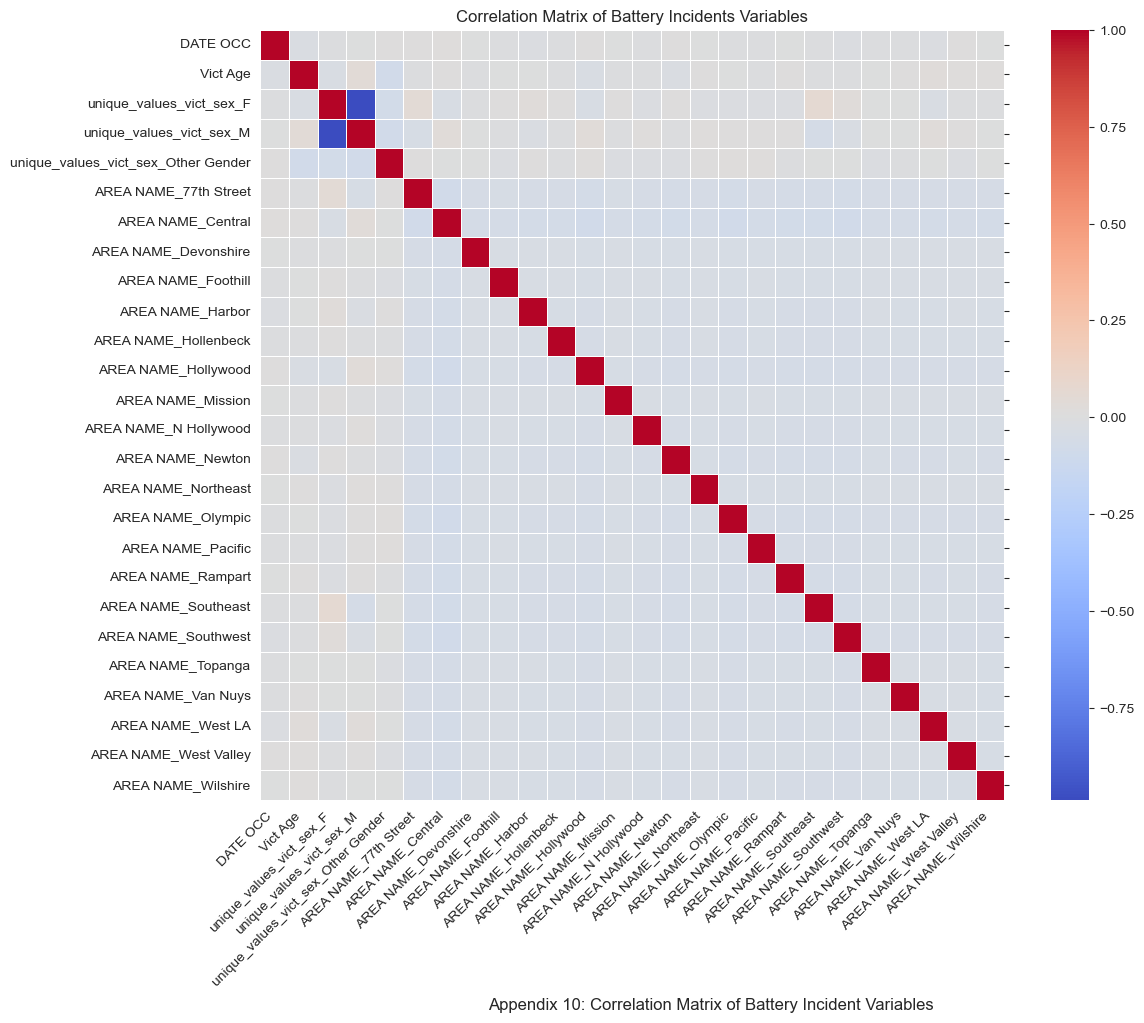

In [66]:
# Select relevant columns for correlation analysis
relevant_columns = ['DATE OCC', 'Vict Age', 'unique_values_vict_sex', 'AREA NAME']

# Subset the DataFrame with relevant columns
subset_df = df_simple_assault[relevant_columns]

# Encode categorical variables for correlation analysis
encoded_df = pd.get_dummies(subset_df, columns=['unique_values_vict_sex', 'AREA NAME'])

# Compute the correlation matrix
correlation_matrix = encoded_df.corr()

# Plot the correlation matrix as a heatmap
#plt.figure(figsize=(12, 10))
#sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
#plt.title('Correlation Matrix of Battery Incidents Variables')
#plt.xticks(rotation=45, ha='right')
#plt.yticks(rotation=0)
#plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)

plt.tick_params(axis='y', which='both', right=True, left=False)

plt.title('Correlation Matrix of Battery Incidents Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Adding the label
plt.figtext(0.5, -0.1, 'Appendix 10: Correlation Matrix of Battery Incident Variables', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Machine Learning Section

Time Series Analysis 

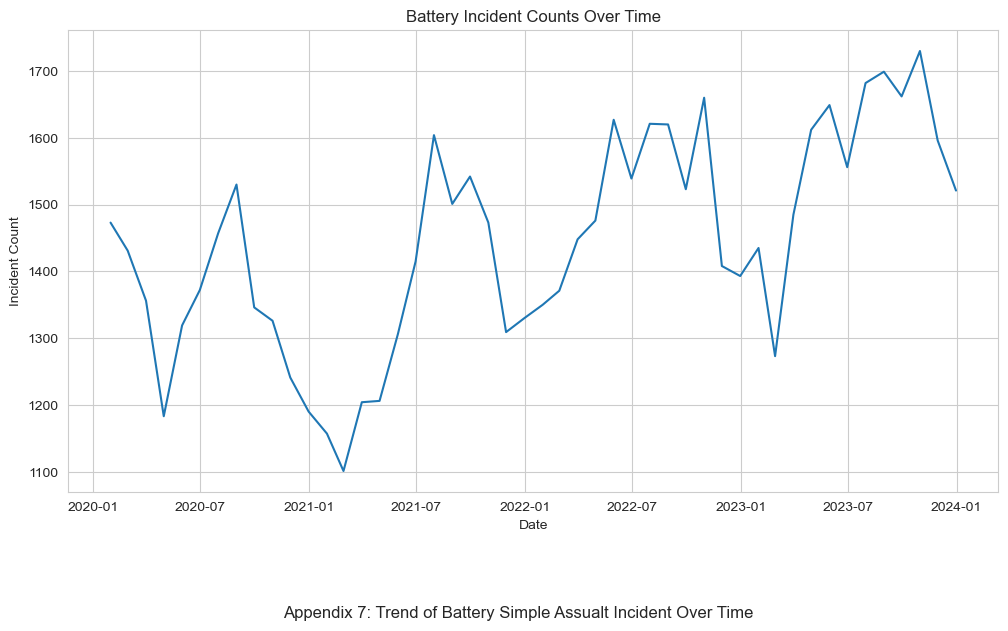

In [67]:
df_simple_assault['Date Rptd'] = pd.to_datetime(df_simple_assault['Date Rptd'])
df_simple_assault.set_index('Date Rptd', inplace=True)

# Prepare the data
incident_counts = df_simple_assault.resample('M').size()  # Resample data by month and get incident counts
incident_counts = incident_counts.fillna(0)  # Fill missing values with 0s

# Visualize the time series data
plt.figure(figsize=(12, 6))
plt.plot(incident_counts)
plt.title('Battery Incident Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Incident Count')
plt.figtext(0.5, -0.1, 'Appendix 7: Trend of Battery Simple Assualt Incident Over Time', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

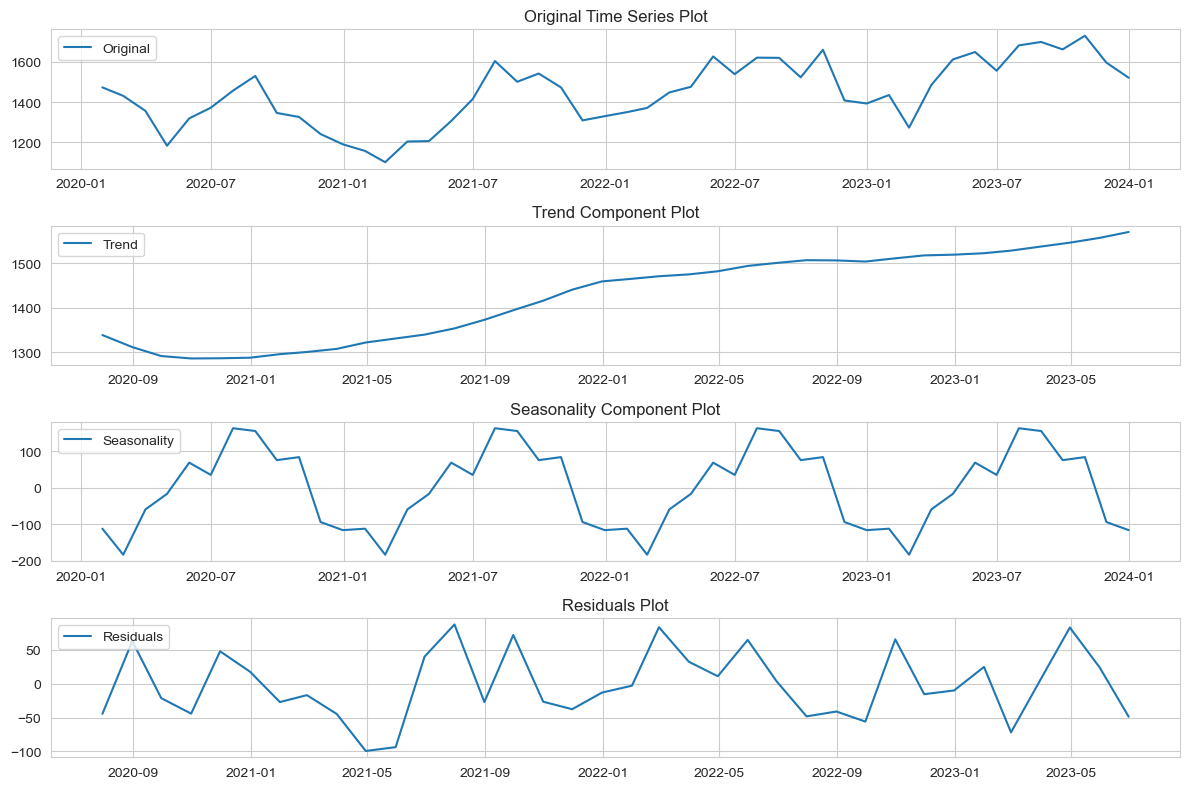

In [68]:
decomposition = seasonal_decompose(incident_counts, model='additive')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(incident_counts, label='Original')
plt.legend(loc='upper left')
plt.title('Original Time Series Plot')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')
plt.title('Trend Component Plot')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.title('Seasonality Component Plot')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')
plt.title('Residuals Plot')

plt.tight_layout()
plt.show()

Battery Simple Assault Forecast Using SARIMA Model

In [69]:
# Train-test split
train_size = int(len(incident_counts) * 0.8)
train_data, test_data = incident_counts[:train_size], incident_counts[train_size:]

# Fit SARIMA model
order = (1, 1, 1)  # ARIMA order (p, d, q)
seasonal_order = (1, 1, 1, 12)  # Seasonal order (P, D, Q, s)
model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)

# Forecast future incident counts
forecast = model_fit.forecast(steps=len(test_data))

# Evaluate the model
mse = mean_squared_error(test_data, forecast)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 10571.340184589557


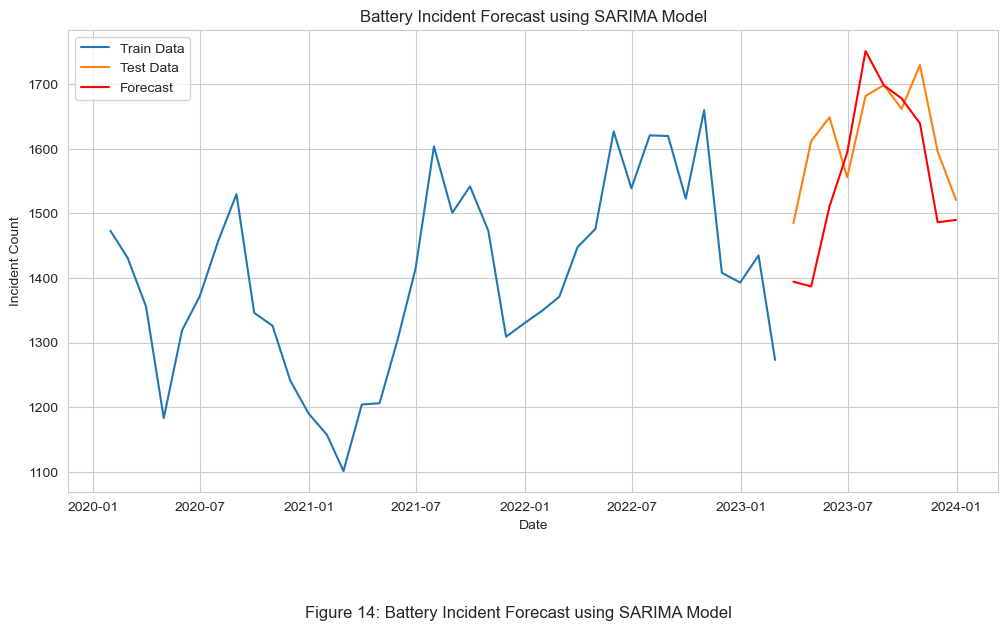

In [70]:
# Visualize the forecast
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, forecast, label='Forecast', color='red')
plt.title('Battery Incident Forecast using SARIMA Model')
plt.xlabel('Date')
plt.ylabel('Incident Count')
plt.legend()
# Adding the label
plt.figtext(0.5, -0.1, 'Figure 14: Battery Incident Forecast using SARIMA Model', wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [73]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [74]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

True

In [75]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


Finaly we did a word cloud visualization to view the more come crime incident in the crime dataset and went further to do a sentiment analysis of the general dataset.

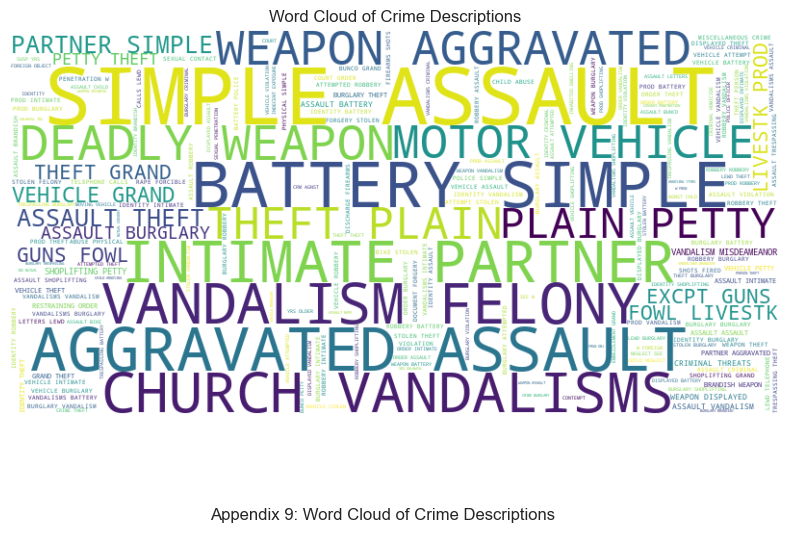

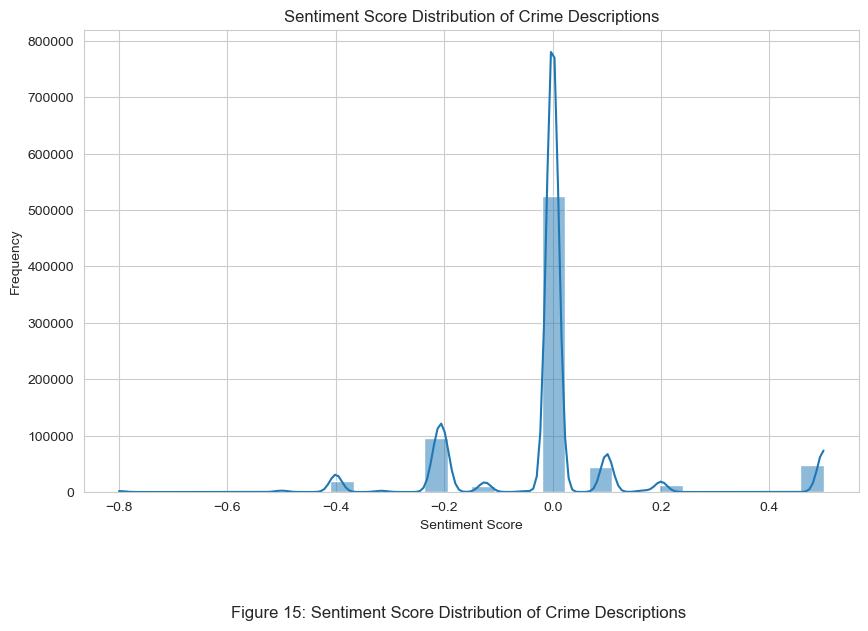

In [76]:
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import nltk

# Perform sentiment analysis on the 'Crime Description' column
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

df_cleaned_specific['Sentiment'] = df_cleaned_specific['Crm Cd Desc'].apply(get_sentiment)

# Create a word cloud of crime descriptions
all_descriptions = ' '.join(df_cleaned_specific['Crm Cd Desc'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_descriptions)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Crime Descriptions')
plt.figtext(0.5, -0.1, 'Appendix 9: Word Cloud of Crime Descriptions', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

# Plot sentiment score distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned_specific['Sentiment'], bins=30, kde=True)
plt.title('Sentiment Score Distribution of Crime Descriptions')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.figtext(0.5, -0.1, 'Figure 15: Sentiment Score Distribution of Crime Descriptions', wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

The word cloud visualization of crime descriptions in Los Angeles provides a visual representation of common themes and issues, enabling stakeholders to quickly identify common crime types and reporting language, and effectively summarizing vast text material.

Kindly refer to the report for further explanation of the general analysis.